In [ ]:
# Prathmesh Durge, 23070521109

import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

# Use raw strings (or forward slashes) on Windows to avoid escape-sequence bugs.
TRAIN_DIR = r"Dog breed Classification\train"
VAL_DIR = r"Dog breed Classification\val"
TEST_DIR = r"Dog breed Classification\test"


In [4]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    label_mode="int"
 )

validation_dataset = keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="int"
 )

test_dataset = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="int"
 )

# Save class names before wrapping datasets with prefetch().
class_names = train_dataset.class_names

# Improve input pipeline performance.
train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

Found 6391 files belonging to 93 classes.
Found 762 files belonging to 93 classes.
Found 887 files belonging to 93 classes.


In [5]:
NUM_CLASSES = len(class_names)

print("Classes:", class_names)
print("Number of classes:", NUM_CLASSES)


Classes: ['afghan_hound', 'african_hunting_dog', 'airedale', 'basenji', 'basset', 'beagle', 'bedlington_terrier', 'bernese_mountain_dog', 'black-and-tan_coonhound', 'blenheim_spaniel', 'bloodhound', 'bluetick', 'border_collie', 'border_terrier', 'borzoi', 'boston_bull', 'bouvier_des_flandres', 'brabancon_griffon', 'bull_mastiff', 'cairn', 'cardigan', 'chesapeake_bay_retriever', 'chow', 'clumber', 'cocker_spaniel', 'collie', 'curly-coated_retriever', 'dhole', 'dingo', 'doberman', 'english_foxhound', 'english_setter', 'entlebucher', 'flat-coated_retriever', 'german_shepherd', 'german_short-haired_pointer', 'golden_retriever', 'gordon_setter', 'great_dane', 'great_pyrenees', 'groenendael', 'ibizan_hound', 'irish_setter', 'irish_terrier', 'irish_water_spaniel', 'irish_wolfhound', 'japanese_spaniel', 'keeshond', 'kerry_blue_terrier', 'komondor', 'kuvasz', 'labrador_retriever', 'leonberg', 'lhasa', 'malamute', 'malinois', 'maltese_dog', 'mexican_hairless', 'miniature_pinscher', 'miniature_sc

In [6]:

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])


In [7]:

# MobileNetV2 expects pixel values in the range [-1, 1]

preprocess_input = keras.applications.mobilenet_v2.preprocess_input



In [8]:

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)


# Freeze pretrained layers initially

base_model.trainable = False


In [9]:
inputs = keras.Input(shape=(224, 224, 3))

# Data augmentation
x = data_augmentation(inputs)

# MobileNetV2 preprocessing
x = preprocess_input(x)

# Feature extraction using pretrained CNN
x = base_model(x, training=False)

# Convert feature maps into a single vector
x = layers.GlobalAveragePooling2D()(x)

# Dropout to reduce overfitting
x = layers.Dropout(0.3)(x)

# Classification layer
outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = keras.Model(inputs, outputs)

In [10]:

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 93)             │       119,133 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,377,117 (9.07 MB)

 Trainable params: 119,133 (465.36 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [24]:

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    )
]


In [13]:

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 49s 232ms/step - accuracy: 0.5217 - loss: 2.0314 - val_accuracy: 0.8255 - val_loss: 0.7039 - learning_rate: 0.0010
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 72s 360ms/step - accuracy: 0.7686 - loss: 0.8407 - val_accuracy: 0.8478 - val_loss: 0.5448 - learning_rate: 0.0010
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 59s 294ms/step - accuracy: 0.8054 - loss: 0.6683 - val_accuracy: 0.8530 - val_loss: 0.5178 - learning_rate: 0.0010
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 54s 267ms/step - accuracy: 0.8277 - loss: 0.5810 - val_accuracy: 0.8478 - val_loss: 0.4881 - learning_rate: 0.0010
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 50s 249ms/step - accuracy: 0.8440 - loss: 0.5196 - val_accuracy: 0.8556 - val_loss: 0.4993 - learning_rate: 0.0010
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 51s 253ms/step - accuracy: 0.8626 - loss: 0.4525 - val_accuracy: 0.8543 - val_loss: 0.4969 - learning_rate: 0.0010
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 48s 242ms/step - accuracy: 0.8

In [14]:
print("\nStarting Fine-Tuning...")


# Unfreeze MobileNetV2

base_model.trainable = True


# Freeze most of the layers
# Fine-tune only the last 30 layers

for layer in base_model.layers[:-30]:
    layer.trainable = False


# Recompile with a very small learning rate

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)



Starting Fine-Tuning...


In [25]:

fine_tune_history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    callbacks=callbacks
)


Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 61s 304ms/step - accuracy: 0.8274 - loss: 0.5916 - val_accuracy: 0.8530 - val_loss: 0.4691 - learning_rate: 2.0000e-06
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 63s 312ms/step - accuracy: 0.8362 - loss: 0.5561 - val_accuracy: 0.8543 - val_loss: 0.4795 - learning_rate: 2.0000e-06
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 62s 312ms/step - accuracy: 0.8399 - loss: 0.5506 - val_accuracy: 0.8543 - val_loss: 0.4873 - learning_rate: 2.0000e-06
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 61s 305ms/step - accuracy: 0.8329 - loss: 0.5598 - val_accuracy: 0.8491 - val_loss: 0.4970 - learning_rate: 4.0000e-07
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 59s 294ms/step - accuracy: 0.8299 - loss: 0.5567 - val_accuracy: 0.8517 - val_loss: 0.5063 - learning_rate: 4.0000e-07
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 60s 302ms/step - accuracy: 0.8366 - loss: 0.5553 - val_accuracy: 0.8465 - val_loss: 0.5151 - learning_rate: 1.0000e-07


In [16]:

test_loss, test_accuracy = model.evaluate(test_dataset)

print("\n====================================")
print("TEST RESULTS")
print("====================================")

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 189ms/step - accuracy: 0.8873 - loss: 0.3661

TEST RESULTS
Test Loss: 0.3660949766635895
Test Accuracy: 0.8872604370117188


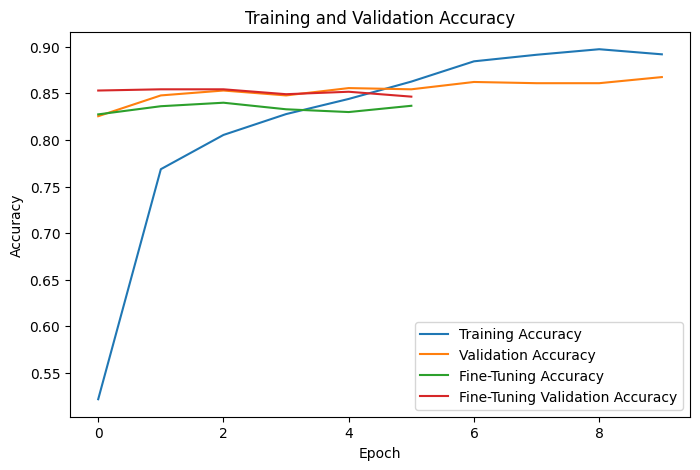

In [31]:

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.plot(
    fine_tune_history.history["accuracy"],
    label="Fine-Tuning Accuracy"
)

plt.plot(
    fine_tune_history.history["val_accuracy"],
    label="Fine-Tuning Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.show()

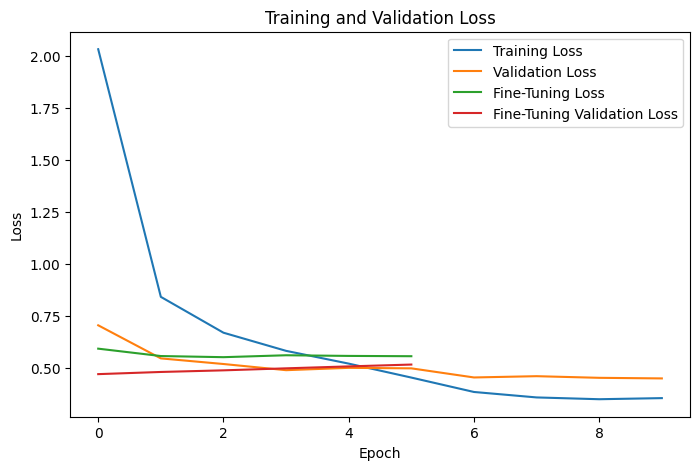

In [32]:

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.plot(
    fine_tune_history.history["loss"],
    label="Fine-Tuning Loss"
)

plt.plot(
    fine_tune_history.history["val_loss"],
    label="Fine-Tuning Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

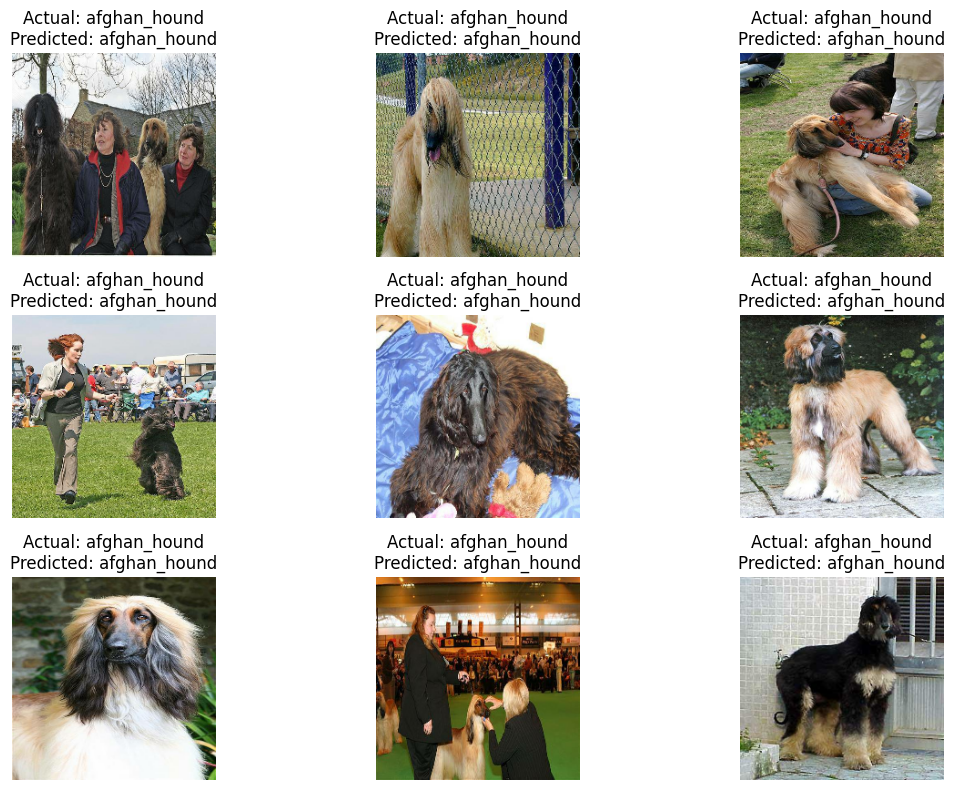

In [22]:
plt.figure(figsize=(12, 8))

for images, labels in test_dataset.take(1):

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    for i in range(min(9, len(images))):

        plt.subplot(3, 3, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        actual = class_names[labels[i]]
        predicted = class_names[predicted_classes[i]]

        plt.title(
            f"Actual: {actual}\nPredicted: {predicted}"
        )

        plt.axis("off")

plt.tight_layout()
plt.show()


In [23]:

model.save("dog_breed_mobilenetv2.keras")

print("\nModel saved successfully!")


Model saved successfully!
